In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score

In [80]:
df=pd.read_csv("Social_Network_Ads.csv")
print("First 5 rows: ")
print(df.head())

print("Columns: ")
print(df.columns)

First 5 rows: 
    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0
Columns: 
Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')


In [81]:
print(df.isnull().sum())
print(df.shape)

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64
(400, 5)


In [82]:
df['Gender']=df['Gender'].map({"Male":0,"Female":1})
X=df[['Gender','Age', 'EstimatedSalary']]
y=df['Purchased']

x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [83]:
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [84]:
classifier=LogisticRegression()
classifier.fit(x_train,y_train)
y_pred=classifier.predict(x_test)


In [85]:
cm=confusion_matrix(y_test,y_pred)
print("Confusion matrix: ",cm)

TN,FP,FN,TP=cm.ravel()
accuracy=accuracy_score(y_test,y_pred)
errorRate=1-accuracy
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)

print("True negative: ",TN)
print("False Positive: ",FP)
print("False negative: ",FN)
print("True positive: ",TP)
print("Accuracy score: ",accuracy)
print("Error rate: ",errorRate)
print("Precision score: ",precision)
print("Recall score: ",precision)

Confusion matrix:  [[61  2]
 [10 27]]
True negative:  61
False Positive:  2
False negative:  10
True positive:  27
Accuracy score:  0.88
Error rate:  0.12
Precision score:  0.9310344827586207
Recall score:  0.9310344827586207


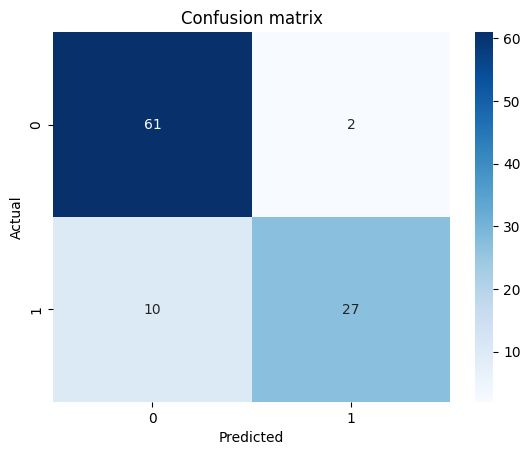

In [86]:
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.show()